In [1]:
!pip install gdown

In [2]:
!pip install google-api-python-client google-auth-httplib2 google-auth-oauthlib

## **Loading Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from googleapiclient.discovery import build
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file('/content/drive/MyDrive/Colab Notebooks/credentials (1).json')
service = build('drive', 'v3', credentials=credentials)

folder_id = "1Kok05OPVESTpyyan7NafR-2WwuSJ4TO9"

# List files in the folder
results = service.files().list(q=f"'{folder_id}' in parents", fields="files(id, name)").execute()
files = results.get('files', [])
print("Files in the folder:")
for file in files:
    print(f"Name: {file['name']}, ID: {file['id']}")

Files in the folder:
Name: Past_nogauge, ID: 1yzUyue4Law-deT8NjPe4pcFzuSB_FMrv
Name: NRT, ID: 1QzLe6EX4txOdf8lnY5l-ofLxKInvBgaL
Name: Past, ID: 1nBJFXqyQuWLvCh0xrBi89bpn-WG92iMV


In [5]:
import os
import io
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from google.oauth2 import service_account

# Google Drive API credentials
credentials = service_account.Credentials.from_service_account_file(
    '/content/drive/MyDrive/Colab Notebooks/credentials (1).json',
    scopes=["https://www.googleapis.com/auth/drive"]
)
service = build('drive', 'v3', credentials=credentials)

# Replace 'FOLDER_ID' with the root folder ID
root_folder_id = "1Kok05OPVESTpyyan7NafR-2WwuSJ4TO9"

# Directory to save downloaded files
download_directory = "/content/drive/My Drive/Colab Notebooks/dataset4"
os.makedirs(download_directory, exist_ok=True)

# Recursive function to navigate folders and download files
def download_files_in_folder(folder_id, current_path):
    # Create subfolder locally
    os.makedirs(current_path, exist_ok=True)

    # List all files and subfolders in the current folder
    results = service.files().list(q=f"'{folder_id}' in parents", fields="files(id, name, mimeType)").execute()
    items = results.get('files', [])

    for item in items:
        file_id = item['id']
        file_name = item['name']
        mime_type = item['mimeType']

        if mime_type == 'application/vnd.google-apps.folder':
            # If the item is a folder, call the function recursively
            subfolder_path = os.path.join(current_path, file_name)
            download_files_in_folder(file_id, subfolder_path)
        elif file_name.endswith('.nc'):
            # If the file is an .nc file, download it
            file_path = os.path.join(current_path, file_name)
            request = service.files().get_media(fileId=file_id)
            with io.FileIO(file_path, 'wb') as fh:
                downloader = MediaIoBaseDownload(fh, request)
                done = False
                while not done:
                    status, done = downloader.next_chunk()
                    print(f"Downloaded {file_name} to {file_path}")

# Start the recursive download process from the root folder
download_files_in_folder(root_folder_id, download_directory)


Downloaded 2007206.00.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2007206.00.nc
Downloaded 2010144.06.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2010144.06.nc
Downloaded 2007129.03.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2007129.03.nc
Downloaded 2009159.06.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2009159.06.nc
Downloaded 2008070.09.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2008070.09.nc
Downloaded 2009136.03.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2009136.03.nc
Downloaded 2007199.09.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2007199.09.nc
Downloaded 2010120.06.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2010120.06.nc
Downloaded 2008284.06.nc to /content/drive/My Drive/Colab Notebooks/dataset4/Past_nogauge/3hourly/200828

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
def load_nc_files_from_folders(base_folder):
    """
    Loads all NetCDF (.nc) files from the specified folder and its subfolders.

    Parameters:
    base_folder (str): The base folder to start searching for .nc files.

    Returns:
    list: A list of xarray datasets.
    """
    # List to store datasets
    datasets = []

    # Walk through the directory and subdirectories
    for root, dirs, files in os.walk(base_folder):
        for file in files:
            if file.endswith('.nc'):
                # Construct the full file path
                file_path = os.path.join(root, file)
                print(f"Loading dataset: {file_path}")

                # Open the NetCDF file using xarray
                try:
                    dataset = xr.open_dataset(file_path)
                    datasets.append(dataset)
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")

    return datasets
# Specify the base folder where subfolders (daily, monthly, hourly) are located
base_folder = '/content/drive/MyDrive/Colab Notebooks/dataset4'

# Load all datasets from the folder and subfolders
datasets = load_nc_files_from_folders(base_folder)

# Check the number of datasets loaded
print(f"Total datasets loaded: {len(datasets)}")

Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2007180.03.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2008223.06.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2009230.15.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2007331.18.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2008059.15.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2008119.03.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2009131.18.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2009249.12.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2008305.18.nc
Loading dataset: /content/drive/MyDrive/Colab Notebooks/dataset4/Past_nogauge/3hourly/2009363.21.nc


## **Exploratory Data Analysis**

In [46]:
print(f"Dimensions of the first dataset: {datasets[10].dims}")
print(f"Variables of the first dataset: {datasets[10].variables}")

Dimensions of the first dataset: FrozenMappingWarningOnValuesAccess({'lon': 3600, 'lat': 1800, 'time': 1})
Variables of the first dataset: Frozen({'lon': <xarray.IndexVariable 'lon' (lon: 3600)> Size: 14kB
array([-179.95   , -179.84999, -179.75   , ...,  179.75002,  179.85002,
        179.95   ], dtype=float32)
Attributes:
    units:      degrees_east
    long_name:  longitude, 'lat': <xarray.IndexVariable 'lat' (lat: 1800)> Size: 7kB
array([ 89.95    ,  89.85    ,  89.75    , ..., -89.75    , -89.850006,
       -89.95001 ], dtype=float32)
Attributes:
    units:      degrees_north
    long_name:  latitude, 'time': <xarray.IndexVariable 'time' (time: 1)> Size: 8B
array(['2009-04-23T00:00:00.000000000'], dtype='datetime64[ns]')
Attributes:
    long_name:  time, 'precipitation': <xarray.Variable (time: 1, lat: 1800, lon: 3600)> Size: 26MB
array([[[0.125 , 0.125 , ..., 0.125 , 0.125 ],
        [0.0625, 0.0625, ..., 0.0625, 0.0625],
        ...,
        [0.    , 0.    , ..., 0.    , 0.    ]

In [9]:
import numpy as np

dataset = datasets[0]

# Get the 'precipitation' variable from the dataset
precipitation = dataset['precipitation']

# Display basic summary statistics for the precipitation variable
mean_precip = precipitation.mean().values
std_precip = precipitation.std().values
min_precip = precipitation.min().values
max_precip = precipitation.max().values
median_precip = precipitation.median().values

# Print the summary statistics
print(f"Mean Precipitation: {mean_precip}")
print(f"Standard Deviation of Precipitation: {std_precip}")
print(f"Min Precipitation: {min_precip}")
print(f"Max Precipitation: {max_precip}")
print(f"Median Precipitation: {median_precip}")


Mean Precipitation: 0.3056747019290924
Standard Deviation of Precipitation: 1.121694564819336
Min Precipitation: 0.0
Max Precipitation: 105.375
Median Precipitation: 0.0


In [10]:
import pandas as pd

# Convert precipitation variable to a pandas DataFrame
precipitation_values = precipitation.values.flatten()  # Flatten the 3D array into 1D
precipitation_series = pd.Series(precipitation_values)

# Use pandas describe to get detailed summary statistics
precipitation_stats = precipitation_series.describe()

# Print the summary statistics
print(precipitation_stats)

count    6.480000e+06
mean     3.099976e-01
std      1.121695e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.250000e-01
max      1.053750e+02
dtype: float64


In [11]:
# Extract time values from all datasets
time_values = [ds['time'].values[0] for ds in datasets]

# Print the time range
print(f"Earliest time: {min(time_values)}")
print(f"Latest time: {max(time_values)}")
print(f"Total time points: {len(time_values)}")

Earliest time: 1979-02-01T00:00:00.000000000
Latest time: 2025-02-11T15:00:00.000000000
Total time points: 848


In [12]:
import numpy as np

# Convert time_values to a numpy array
time_array = np.array(time_values)

# Calculate the time differences between consecutive time points
time_diffs = np.diff(time_array)

# Print the unique time differences
unique_time_diffs = np.unique(time_diffs)
print("Unique time differences between consecutive time points:")
print(unique_time_diffs)

Unique time differences between consecutive time points:
[-1272520800000000000 -1257033600000000000 -1175558400000000000
 -1158796800000000000 -1117497600000000000 -1101945600000000000
 -1067385600000000000 -1059782400000000000 -1022457600000000000
  -946771200000000000  -933552000000000000  -925257600000000000
  -917913600000000000  -909878400000000000  -907977600000000000
  -882057600000000000  -877132800000000000  -861840000000000000
  -831081600000000000  -826070400000000000  -754790400000000000
  -746150400000000000  -680832000000000000  -661996800000000000
  -660009600000000000  -657504000000000000  -654739200000000000
  -632448000000000000  -630115200000000000  -615254400000000000
  -601171200000000000  -591753600000000000  -533865600000000000
  -533779200000000000  -512784000000000000  -504921600000000000
  -486518400000000000  -478569600000000000  -476582400000000000
  -473385600000000000  -472176000000000000  -462067200000000000
  -448848000000000000  -439171200000000000  -42

In [13]:
# Convert time differences to seconds (as a numeric type)
time_diffs_seconds = time_diffs.astype('timedelta64[s]').astype(float)

# Find indices where time differences are negative
out_of_order_indices = np.where(time_diffs_seconds < 0)[0]

# Print the out-of-order time points
for idx in out_of_order_indices:
    print(f"Time point {idx}: {time_values[idx]} (out of order)")

Time point 2: 2009-08-18T15:00:00.000000000 (out of order)
Time point 7: 2009-09-06T12:00:00.000000000 (out of order)
Time point 9: 2009-12-29T21:00:00.000000000 (out of order)
Time point 11: 2010-01-06T03:00:00.000000000 (out of order)
Time point 12: 2009-06-28T09:00:00.000000000 (out of order)
Time point 13: 2009-06-10T03:00:00.000000000 (out of order)
Time point 14: 2008-12-03T18:00:00.000000000 (out of order)
Time point 16: 2008-03-17T00:00:00.000000000 (out of order)
Time point 20: 2010-04-25T12:00:00.000000000 (out of order)
Time point 21: 2009-05-02T15:00:00.000000000 (out of order)
Time point 23: 2009-08-31T06:00:00.000000000 (out of order)
Time point 25: 2010-05-24T06:00:00.000000000 (out of order)
Time point 27: 2009-06-08T06:00:00.000000000 (out of order)
Time point 29: 2009-05-16T03:00:00.000000000 (out of order)
Time point 31: 2010-04-30T06:00:00.000000000 (out of order)
Time point 33: 2009-08-29T15:00:00.000000000 (out of order)
Time point 36: 2010-02-28T03:00:00.00000000

In [14]:
# Sort datasets by time
sorted_indices = np.argsort(time_values)
sorted_datasets = [datasets[i] for i in sorted_indices]
sorted_time_values = [time_values[i] for i in sorted_indices]

# Verify that the time points are now in order
sorted_time_diffs = np.diff(sorted_time_values)
out_of_order_indices = np.where(sorted_time_diffs < np.timedelta64(0, 's'))[0]

if len(out_of_order_indices) == 0:
    print("All time points are now in chronological order.")
else:
    print("There are still out-of-order time points.")

All time points are now in chronological order.


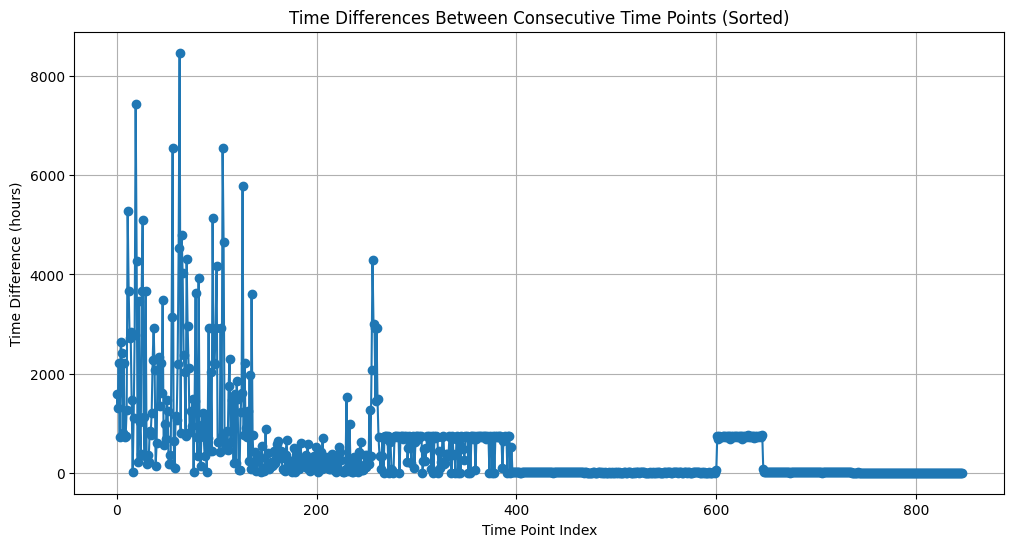

In [15]:
# Convert time differences to hours for better readability
sorted_time_diffs_hours = sorted_time_diffs.astype('timedelta64[h]').astype(float)

# Plot the time differences
plt.figure(figsize=(12, 6))
plt.plot(sorted_time_diffs_hours, marker='o', linestyle='-')
plt.xlabel('Time Point Index')
plt.ylabel('Time Difference (hours)')
plt.title('Time Differences Between Consecutive Time Points (Sorted)')
plt.grid()
plt.show()

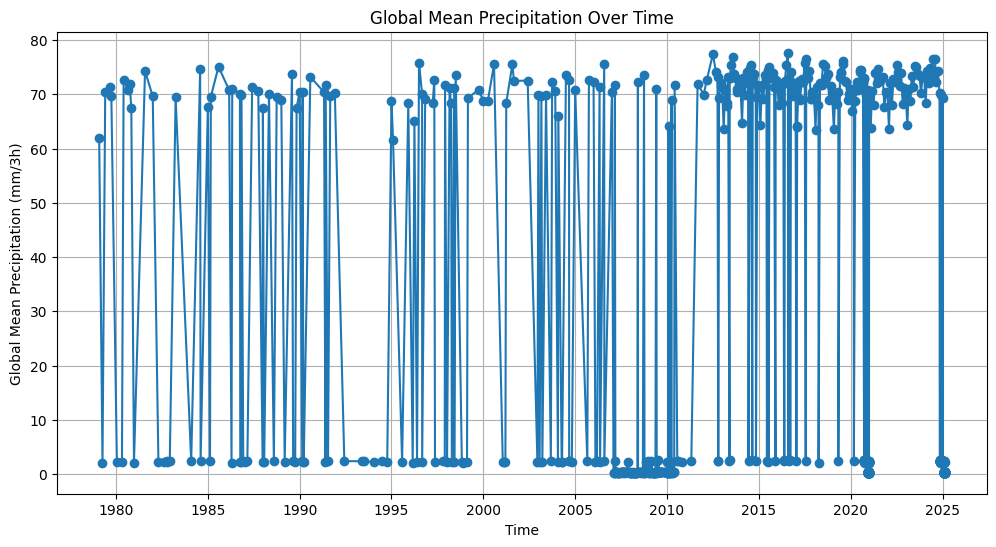

In [33]:
# Calculate global mean precipitation for each dataset
global_mean_precip = [ds['precipitation'].mean().values for ds in sorted_datasets]

# Plot the time series of global mean precipitation
plt.figure(figsize=(12, 6))
plt.plot(sorted_time_values, global_mean_precip, marker='o')
plt.xlabel('Time')
plt.ylabel('Global Mean Precipitation (mm/3h)')
plt.title('Global Mean Precipitation Over Time')
plt.grid()
plt.show()

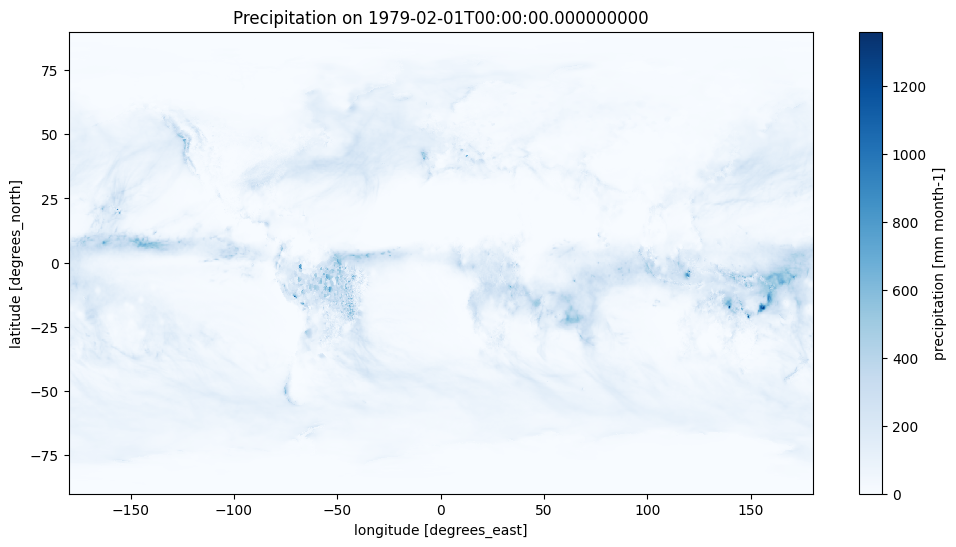

In [44]:
# Plot precipitation for the first dataset
sorted_datasets[0]['precipitation'].plot(cmap='Blues', figsize=(12, 6))
plt.title(f"Precipitation on {sorted_time_values[0]}")
plt.show()

In [20]:
# Find the dataset with the highest maximum precipitation
max_precip_values = [ds['precipitation'].max().values for ds in sorted_datasets]
max_dataset_index = np.argmax(max_precip_values)
max_dataset = sorted_datasets[max_dataset_index]

# Find the dataset with the lowest minimum precipitation
min_precip_values = [ds['precipitation'].min().values for ds in sorted_datasets]
min_dataset_index = np.argmin(min_precip_values)
min_dataset = sorted_datasets[min_dataset_index]

# Print the results
print(f"Time point with highest precipitation: {sorted_time_values[max_dataset_index]}")
print(f"Maximum precipitation: {max_precip_values[max_dataset_index]} mm/3h")
print(f"Time point with lowest precipitation: {sorted_time_values[min_dataset_index]}")
print(f"Minimum precipitation: {min_precip_values[min_dataset_index]} mm/3h")

Time point with highest precipitation: 1997-04-01T00:00:00.000000000
Maximum precipitation: 9819.5 mm/3h
Time point with lowest precipitation: 1979-02-01T00:00:00.000000000
Minimum precipitation: 0.0 mm/3h


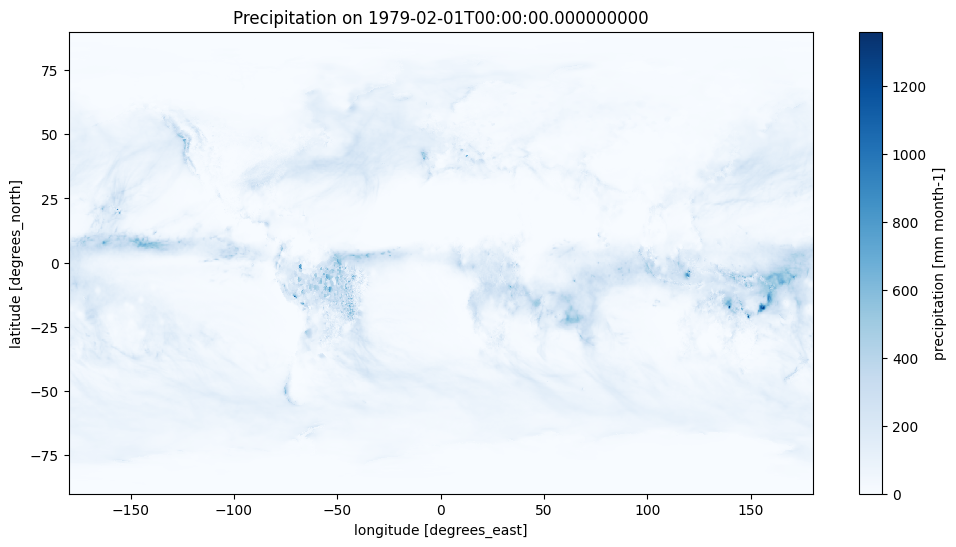

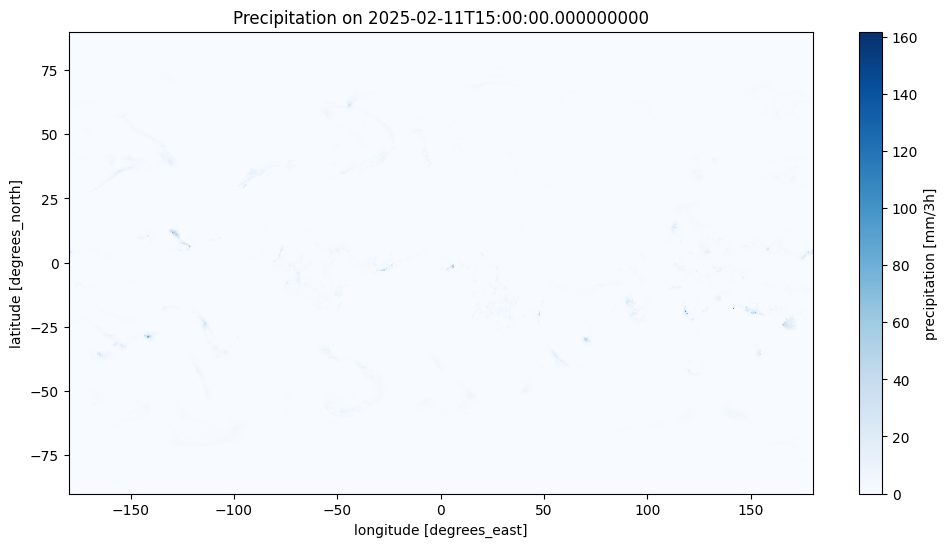

In [21]:
# Plot precipitation for the first dataset
plt.figure(figsize=(12, 6))
sorted_datasets[0]['precipitation'].plot(cmap='Blues')
plt.title(f"Precipitation on {sorted_time_values[0]}")
plt.show()

# Plot precipitation for the last dataset
plt.figure(figsize=(12, 6))
sorted_datasets[-1]['precipitation'].plot(cmap='Blues')
plt.title(f"Precipitation on {sorted_time_values[-1]}")
plt.show()

In [45]:
print(datasets[0])  # Inspect the first dataset

<xarray.Dataset> Size: 26MB
Dimensions:        (lon: 3600, lat: 1800, time: 1)
Coordinates:
  * lon            (lon) float32 14kB -179.9 -179.8 -179.8 ... 179.8 179.9 179.9
  * lat            (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * time           (time) datetime64[ns] 8B 2007-06-29T03:00:00
Data variables:
    precipitation  (time, lat, lon) float32 26MB 0.625 0.625 ... 0.0625 0.0625
Attributes:
    history:  Created on 2022-10-08 22:16


In [36]:
print(datasets[393])

<xarray.Dataset> Size: 104MB
Dimensions:            (lon: 3600, lat: 1800, time: 1)
Coordinates:
  * lon                (lon) float32 14kB -179.9 -179.8 -179.8 ... 179.9 179.9
  * lat                (lat) float32 7kB 89.95 89.85 89.75 ... -89.85 -89.95
  * time               (time) datetime64[ns] 8B 2025-01-31T21:00:00
Data variables:
    combination        (time, lat, lon) float32 26MB ...
    cumulative_weight  (time, lat, lon) float32 26MB ...
    precipitation      (time, lat, lon) float64 52MB 0.2146 0.2146 ... 0.002718
Attributes:
    history:          Created on 2025-02-01 01:31
    input_data_hash:  c397c886f32e260fd178517e676802cf1d3a8ef348980d441118d87...


In [47]:
print(datasets[811])

<xarray.Dataset> Size: 26MB
Dimensions:        (lon: 3600, lat: 1800, time: 1)
Coordinates:
  * lon            (lon) float32 14kB -179.9 -179.8 -179.8 ... 179.8 179.9 179.9
  * lat            (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * time           (time) datetime64[ns] 8B 1980-12-24
Data variables:
    precipitation  (time, lat, lon) float32 26MB 0.4375 0.4375 ... 0.0625 0.0625
Attributes:
    history:  Created on 2021-02-03 23:20


In [48]:
# Check for missing values in each dataset
missing_values = [ds['precipitation'].isnull().sum().values for ds in sorted_datasets]

# Print summary of missing values
total_missing = np.sum(missing_values)
print(f"Total missing values across all datasets: {total_missing}")

# Check missing values per dataset
for i, count in enumerate(missing_values):
    print(f"Dataset {i} - Time: {sorted_time_values[i]} - Missing Values: {count}")

Total missing values across all datasets: 0
Dataset 0 - Time: 1979-02-01T00:00:00.000000000 - Missing Values: 0
Dataset 1 - Time: 1979-04-08T00:00:00.000000000 - Missing Values: 0
Dataset 2 - Time: 1979-06-01T00:00:00.000000000 - Missing Values: 0
Dataset 3 - Time: 1979-09-01T00:00:00.000000000 - Missing Values: 0
Dataset 4 - Time: 1979-10-01T00:00:00.000000000 - Missing Values: 0
Dataset 5 - Time: 1980-01-19T00:00:00.000000000 - Missing Values: 0
Dataset 6 - Time: 1980-04-29T00:00:00.000000000 - Missing Values: 0
Dataset 7 - Time: 1980-06-01T00:00:00.000000000 - Missing Values: 0
Dataset 8 - Time: 1980-09-01T00:00:00.000000000 - Missing Values: 0
Dataset 9 - Time: 1980-10-01T00:00:00.000000000 - Missing Values: 0
Dataset 10 - Time: 1980-11-01T00:00:00.000000000 - Missing Values: 0
Dataset 11 - Time: 1980-12-24T00:00:00.000000000 - Missing Values: 0
Dataset 12 - Time: 1981-08-01T00:00:00.000000000 - Missing Values: 0
Dataset 13 - Time: 1982-01-01T00:00:00.000000000 - Missing Values: 0


In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Feb 12 02:07:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!
